In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

### Loading Diabetes dataset for Binary Classification and iris for Multiple Classification

In [13]:
df = pd.read_csv("data/heart.csv")
X_iris , y_iris = load_iris(return_X_y=True)

X_diabetes = df.drop(columns=['target'])
y_diabetes = df['target']

In [14]:
X_train_diabetes , X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(X_diabetes, y_diabetes, test_size=0.3, random_state=0)
X_train_iris , X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.3, random_state=0)

In [15]:
clf_diabetes = LogisticRegression()
clf_iris = LogisticRegression()

clf_diabetes.fit(X_train_diabetes, y_train_diabetes)
clf_iris.fit(X_train_iris, y_train_iris)

y_pred_diabetes = clf_diabetes.predict(X_test_diabetes)
y_pred_iris = clf_iris.predict(X_test_iris)

C:\Users\Keval\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Accuracy Score

#### `accuracy_score = Total No. of Correct Prediction / Total No of Prediction`

For Multi-Classification accuracy_score works the same

In [16]:
print(f"Accuracy Score For Diabetes : {accuracy_score(y_test_diabetes, y_pred_diabetes)}")
print(f"Accuracy Score For Iris : {accuracy_score(y_test_iris, y_pred_iris)}")

Accuracy Score For Diabetes : 0.8701298701298701
Accuracy Score For Iris : 0.9777777777777777


#### The problem with Accuracy Score is it doesn't tell which is the type of error?

#### To solve this Confustion Matrix is used.

#### Before Moving to Confusion Matrix Let's understand Type of Error

`Type 1 error` : When Model predicts positive but it's actually Negative.

`Type 2 error` : When Model predicts Negative but it's actually Positive.

# Confusion Matrix

In [17]:
print("confusion_matrix for Diabetes :\n")
print(confusion_matrix(y_test_diabetes, y_pred_diabetes))

confusion_matrix for Diabetes :

[[118  27]
 [ 13 150]]


Here there are 4 Numbers 

1. `True Positive (TP)` : when model predicts positive and it is actually positive In matrix it is `118`
2. `False Negative (FN)` : when model predicts Negative and it is actually positive In matrix it is `27` and also this is `Type 2 error`
2. `False Positive (FP)` : when model predicts Positive and it is actually Negative In matrix it is `13` and also this is `Type 1 error`
2. `True Negative (TN)` : when model predicts Negative and it is actually Negative In matrix it is `150`

We can also calculate the accuracy score from Confusion Matrix

`accuracy_score = (TP + TN) / (TP + FN + FP + TN)`

In [18]:
accuracy = (118 + 150) / (118+27+13+150)
print(f"Accuracy Score from Confusion Matrix : {accuracy}")
print(f"Accuracy Score : {accuracy_score(y_test_diabetes, y_pred_diabetes)}")

Accuracy Score from Confusion Matrix : 0.8701298701298701
Accuracy Score : 0.8701298701298701


Now Let's see Confusion Matrix for Multi-Classification

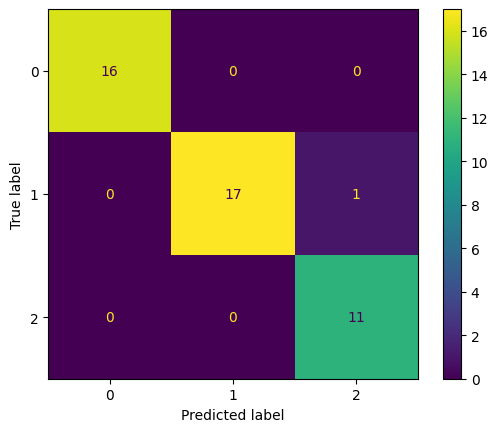

In [23]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_iris, y_pred_iris),
    display_labels=clf_iris.classes_ 
)

disp.plot()

plt.show()

Here Confusion Matrix has `9` values 

Take a look at the value `1` it shows that the actual values is 1 but Model predicted 2

---

# Precision

### It shows the How many are correctly predicted positive out of all positives

### `precision = TP / (TP + FP)`

#### It is used when False Positive(FP) ( `Type 1 Error` ) is more dangerous and whichever model has high Precision will be choosen.


Example : Email Spam Detection

In this model you want your model to predict the email is spam or not. So, you don't want you important emails to go in spam section means your False Positive that's when you use precision


In [25]:
precision_diabetes = precision_score(y_test_diabetes, y_pred_diabetes)
precision_iris = precision_score(y_test_iris, y_pred_iris,average='weighted')

print(f"Precision Score For Diabetes : {precision_diabetes}")
print(f"Precision Score For Iris : {precision_iris}")

Precision Score For Diabetes : 0.847457627118644
Precision Score For Iris : 0.9796296296296295


# Recall

### It shows the proportion of actual Positive that are correctly classifed

### `precision = TP / (TP + FN)`

#### It is used when False Negative(FP) ( `Type 2 Error` ) is more dangerous and whichever model has high Recall will be choosen.


Example : Cancer Detection

In this model you want your model to predict accurately when person has cancer. You care about the person has cancer not about person with no cancer


In [26]:
recall_diabetes = recall_score(y_test_diabetes, y_pred_diabetes)
recall_iris = recall_score(y_test_iris, y_pred_iris,average='weighted')

print(f"Recall Score For Diabetes : {recall_diabetes}")
print(f"Recall Score For Iris : {recall_iris}")

Recall Score For Diabetes : 0.9202453987730062
Recall Score For Iris : 0.9777777777777777


# F1 Score 

### The F1 score is the harmonic mean of Precision and Recall. Unlike a regular average, a harmonic mean punishes extreme imbalances.

### `F1 score = 2 * Precision * Recall / (Precision + Recall)`

### If precision is 0.20 and recall is 0.80, then f1 = 0.32 exactly like said more bending towards the Precision.
### If precision is 0 and recall is 1, then f1 = 0

### When it is used ?

#### It is used when You care equally about both types of mistakes balancing False Positives and False Negatives.

Example : Customer Churn Prediction 

You want to catch people about to leave, but you don't want to waste too many discount coupons on people who were going to stay anyway.

In [32]:
f1_diabetes = f1_score(y_test_diabetes, y_pred_diabetes)
f1_iris = f1_score(y_test_iris, y_pred_iris, average='weighted')

print("For Diabetes :")
print(f"F1 : {f1_diabetes:.2f}")
print(f"Precision : {precision_diabetes:.2f}")
print(f"Recall : {recall_diabetes:.2f}")

print("~"*30)

print("For Iris :")
print(f"F1 : {f1_iris:.2f}")
print(f"Precision : {precision_iris:.2f}")
print(f"Recall : {recall_iris:.2f}")

For Diabetes :
F1 : 0.88
Precision : 0.85
Recall : 0.92
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
For Iris :
F1 : 0.98
Precision : 0.98
Recall : 0.98


#### As we can see in diabetes the precision is 0.85 and recall is 0.92 so f1 bends towards precision since is is lower than recall

## Calculation for Multiple Classification

### Step 1 : calculate individual precision/recall/f1 score for all classes

### Step 2: Choose a method from Micro / Macro / Weighted / Samples
 
#### Micro-average
Pool the TP, FP, FN counts across **all** classes first, then compute a single precision/recall/F1 from the totals.
 
```
Precision_micro = ΣTP_c / Σ(TP_c + FP_c)
Recall_micro    = ΣTP_c / Σ(TP_c + FN_c)
F1_micro        = 2 · Precision_micro · Recall_micro / (Precision_micro + Recall_micro)
```
 
**Key property:** in standard multi-class, single-label classification (every sample gets exactly one predicted label), every FP for one class is exactly an FN for another. That makes `Precision_micro = Recall_micro = F1_micro = Accuracy`. Micro-average is dominated by frequent classes it reflects overall correctness, not per-class quality.
 
#### Macro-average
Take the unweighted mean of the per-class scores computed in Step 1.
 
```
Precision_macro = (1/n) · Σ Precision_c
Recall_macro    = (1/n) · Σ Recall_c
F1_macro        = (1/n) · Σ F1_c
```
 
Every class counts equally regardless of how many samples it has. This is the method that most exposes poor performance on rare classes a model that ignores a small class entirely will tank the macro score even if accuracy looks fine.
 
#### Weighted-average
Same as macro, but each class's score is weighted by its **support** the number of true instances of that class (`n_c`), out of total `N`.
 
```
Precision_weighted = Σ (n_c / N) · Precision_c
Recall_weighted     = Σ (n_c / N) · Recall_c
F1_weighted         = Σ (n_c / N) · F1_c
```
 
This corrects macro's "every class equal" assumption for imbalanced datasets, while still not collapsing to accuracy like micro does a class-imbalance-aware middle ground.
 
#### Samples-average
Applies only to **multilabel** problems (each sample can have more than one true label not standard multi-class where each sample has exactly one label).
 
Compute precision/recall/F1 **per sample**, across that sample's own set of true and predicted labels, then average across all samples:
 
```
For sample i: Precision_i = |predicted_labels_i ∩ true_labels_i| / |predicted_labels_i|
              Recall_i    = |predicted_labels_i ∩ true_labels_i| / |true_labels_i|
 
Precision_samples = (1/N) · Σ Precision_i     (same pattern for recall, F1)
```
 
Not defined/meaningful for single-label multi-class each sample there has only one label, so there's nothing to aggregate within a sample.
 
### Which one to use
 
| Method | Sensitive to class imbalance | Rare classes matter as much as frequent ones | Valid for |
|---|---|---|---|
| Micro | No — reflects overall accuracy | No | Multi-class, multilabel |
| Macro | Ignores imbalance by design | Yes | Multi-class, multilabel |
| Weighted | Accounts for imbalance | No — scaled by frequency | Multi-class, multilabel |
| Samples | N/A (per-sample basis) | N/A | Multilabel only |